In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [6]:
data = load_breast_cancer()
X = data.data
y = data.target
print("Dataset shape:", X.shape)
print("Classes:", data.target_names)

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
linear_svm = SVC(kernel="linear", C=1)
linear_svm.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [9]:
y_pred = linear_svm.predict(X_test)

In [10]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.956140350877193

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix:
 [[41  2]
 [ 3 68]]


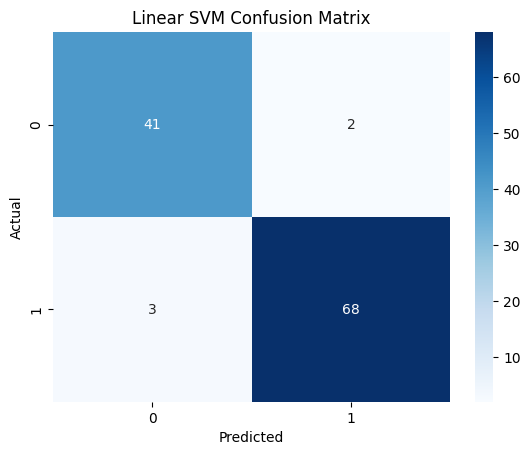

In [11]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
w = linear_svm.coef_[0]
b = linear_svm.intercept_[0]
print("Weight vector w:", w)
print("Bias b:", b)

Weight vector w: [-0.35511707 -0.05395749 -0.27865517 -0.22474276  0.05399718  0.75397417
 -0.65071435 -1.41616626  0.159665   -0.13484858 -1.01396051  0.37135053
 -0.20189503 -0.7741918  -0.33450027  0.36882278  0.24376031 -0.18442378
  0.39129559  0.60282775 -0.59819867 -1.19334172 -0.11808195 -0.55055381
 -0.23020701  0.15313608 -0.75048884 -0.11390086 -0.80267591 -0.52610212]
Bias b: 0.011750100275662104


In [13]:
print("Number of support vectors:", linear_svm.n_support_)

Number of support vectors: [16 20]
